In [1]:
#Compare RNN vs LSTM vs GRU
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Load IMDB dataset
vocab_size = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.imdb.load_data(num_words=vocab_size)

x_train = tf.keras.preprocessing.sequence.pad_sequences(x_train, maxlen=max_len)
x_test = tf.keras.preprocessing.sequence.pad_sequences(x_test, maxlen=max_len)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
def build_model(cell_type):
    model = tf.keras.Sequential()
    model.add(layers.Embedding(vocab_size, 128, input_length=max_len))

    if cell_type == "RNN":
        model.add(layers.SimpleRNN(64))
    elif cell_type == "LSTM":
        model.add(layers.LSTM(64))
    elif cell_type == "GRU":
        model.add(layers.GRU(64))

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])
    return model

histories = {}
for cell in ["RNN", "LSTM", "GRU"]:
    print(f"\nTraining {cell}...")
    model = build_model(cell)
    history = model.fit(x_train, y_train, epochs=3, batch_size=64,
                        validation_data=(x_test, y_test))
    histories[cell] = history


Training RNN...
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


391/391 ━━━━━━━━━━━━━━━━━━━━ 47s 112ms/step - accuracy: 0.6630 - loss: 0.5945 - val_accuracy: 0.7810 - val_loss: 0.4802
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 84s 117ms/step - accuracy: 0.8286 - loss: 0.3901 - val_accuracy: 0.7658 - val_loss: 0.5116
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 44s 112ms/step - accuracy: 0.9099 - loss: 0.2256 - val_accuracy: 0.7846 - val_loss: 0.5833

Training LSTM...
Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 138s 347ms/step - accuracy: 0.7827 - loss: 0.4538 - val_accuracy: 0.8350 - val_loss: 0.3820
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 120s 307ms/step - accuracy: 0.8901 - loss: 0.2748 - val_accuracy: 0.8617 - val_loss: 0.3210
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 134s 344ms/step - accuracy: 0.9274 - loss: 0.1923 - val_accuracy: 0.8602 - val_loss: 0.4099

Training GRU...
Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 146s 366ms/step - accuracy: 0.8035 - loss: 0.4131 - val_accuracy: 0.8586 - val_loss: 0.3333
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 144s 368ms/step - accu

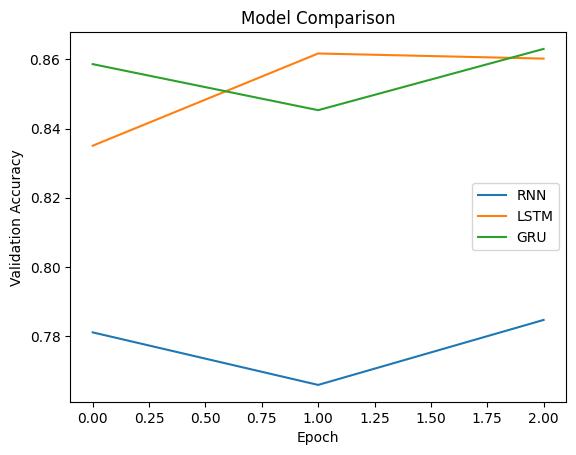

In [4]:
# Plot comparison
for cell in histories:
    plt.plot(histories[cell].history['val_accuracy'], label=cell)

plt.title("Model Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()


